# Classification 'CHURN' avec SMOTE

In [6]:
import sys
import warnings

import pandas as pd


# Load configuration
sys.path.append("../")
warnings.filterwarnings("ignore")

from utils import RANDOM_STATE, TEST_SIZE

EXECUTE_PRIMARY_STEPS = False

# Load the data
df = pd.read_csv("../data/train_data.csv", index_col='ID')

# Feature 'CustomerId' est une erreur est doit être éliminé
df.drop(columns='CustomerId', inplace=True)

# Feature 'Surname' n´a aucune signification pour notre projet
df.drop(columns='Surname', inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
ID,,,,,,,,,,,
37765,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
130453,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
77297,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
40858,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
19804,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


In [7]:
from sklearn.model_selection import train_test_split


y = df.pop("Exited")
X = df.copy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"The X_train set contains: {X_train.shape} elements")
print(f"The y_train set contains: {y_train.shape} elements")
print(f"The X_test set contains: {X_test.shape} elements")
print(f"The y_test set contains: {y_test.shape} elements")

The X_train set contains: (114863, 10) elements
The y_train set contains: (114863,) elements
The X_test set contains: (28716, 10) elements
The y_test set contains: (28716,) elements


## Préparation du pipeline

In [8]:
from sklearn import set_config

set_config(transform_output="pandas")

##### *Remarque* L´encoder OneHot donne de moins bon résultat que LabelEncoder.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


column_preprocessing = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop='first', sparse_output=False), ["Geography", "Gender"])
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False
)

# A faire Feature Engineering:
# - Tester si enlever les outliers de Age améliore le modèle 
# - Tester si grouper catégorie >3 de NumOfProduct améliore le modèle

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.over_sampling import SMOTE

class SMOTETransformer(BaseEstimator, TransformerMixin):
    def __init__(self, sampling_strategy='auto', random_state=RANDOM_STATE):
        self.sampling_strategy = sampling_strategy
        self.random_state = random_state
        self.smote = SMOTE(sampling_strategy=self.sampling_strategy, random_state=self.random_state)

    def fit(self, X, y=None):
        return self  # Pas besoin de fit ici

    def transform(self, X):
        # Transformation seule pas possible car SMOTE a besoin de y
        # Donc on ne l'utilise pas en transform seul, mais via fit_transform
        return X

    def fit_transform(self, X, y=None):
        X_res, y_res = self.smote.fit_resample(X, y)
        return X_res, y_res


In [12]:

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


estimator = Pipeline(
    steps=[
        ("preprocessing", column_preprocessing),
        ("oversampling", SMOTE(random_state=RANDOM_STATE)),
        ('classifier',  LogisticRegression()),
    ],
    
)

estimator

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])],
                                   verbose_feature_names_out=False)),
                ('oversampling', SMOTE(random_state=0)),
                ('classifier', LogisticRegression())])

## Évaluation de la Baseline

In [13]:
# Évaluation d´un baseline modèle
from sklearn.metrics import f1_score


estimator.fit(X_train, y_train)
print("Baseline model training completed.")
baseline_ypred = estimator.predict(X_test)

print("Baseline score:", f1_score(y_true=y_test, y_pred=baseline_ypred))


Baseline model training completed.
Baseline score: 0.48536599729109003


## Entrainement et optimatisation du modèle
### Selection basique des modèles

In [14]:
from typing import Dict, List
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


def run_gridsearch(estimator, params: Dict | List, n_split: int=3):
    cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }

    # Évaluation du meilleur modèle
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=params,
        scoring=scoring,
        refit='f1',
        cv=cv,
        verbose=1,
        n_jobs=-1,
    )

    # Fit GridSearchCV
    print("Starting grid search...")
    grid_search.fit(X_train, y_train)

    # Print the best parameters and score
    print("Best parameters:", grid_search.best_params_)
    print("Best F1-score:", grid_search.best_score_)

    # Get the best model
    return grid_search


def run_randomised_gridsearch(estimator, params: Dict | List, n_iter=50, n_split: int=3):
    cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }

    # Évaluation du meilleur modèle
    grid_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_iter=n_iter,
        scoring=scoring,
        refit='f1',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    # Fit GridSearchCV
    print("Starting grid search...")
    grid_search.fit(X_train, y_train)

    # Print the best parameters and score
    print("Best parameters:", grid_search.best_params_)
    print("Best F1-score:", grid_search.best_score_)

    # Get the best model
    return grid_search

if EXECUTE_PRIMARY_STEPS:
    # Évaluation de la performance 
    models = {
        'classifier': [
            RandomForestClassifier(),
            GradientBoostingClassifier(),
            GaussianNB(),
            BernoulliNB(),
            DecisionTreeClassifier(),
            SVC(),
            MLPClassifier(),
            XGBClassifier(),
            LGBMClassifier(),
            CatBoostClassifier()
        ]
    }

    best_model = run_gridsearch(estimator=estimator, params=models)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def afficher_resultat(grid_search: pd.DataFrame | Pipeline):
    # Convertir cv_results_ en DataFrame
    if not isinstance(grid_search, pd.DataFrame):
        results_df = pd.DataFrame(grid_search.cv_results_)
    else:
        results_df = grid_search.copy()

    # Extraire les colonnes utiles
    plot_df = results_df[[
        'param_classifier',
        'mean_test_f1',
        'mean_test_roc_auc'
    ]]

    # Nettoyer le nom des modèles
    plot_df['param_classifier'] = plot_df['param_classifier'].astype(str).str.extract(r'(\w+)')

    # Trier par F1-score
    plot_df = plot_df.sort_values(by='mean_test_f1', ascending=False)

    # Préparer les données
    labels = plot_df['param_classifier']
    x = np.arange(len(labels))

    # --- Création du graphique ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Barres F1-score (axe 1)
    ax1.bar(x, plot_df['mean_test_f1'], color='skyblue', label='F1-score')
    ax1.set_ylabel('F1-score', color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')

    # Axe X
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right')

    # Second axe pour ROC-AUC
    ax2 = ax1.twinx()
    ax2.plot(x, plot_df['mean_test_roc_auc'], color='orange', marker='o', linewidth=2, label='ROC-AUC')
    ax2.set_ylabel('ROC-AUC', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Titre
    plt.title("Comparaison des modèles : F1-score (barres) vs ROC-AUC (ligne)")

    # Afficher
    plt.tight_layout()
    plt.show()


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Liste des modèles à tester
models = {
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVC": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=1000),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}
if EXECUTE_PRIMARY_STEPS:
    # Figure ROC
    plt.figure(figsize=(10, 7))

    # Boucle sur les modèles
    for name, model in models.items():
        # Remplacer le step "classifier" dans le pipeline
        pipeline = estimator.set_params(classifier=model)
        
        # Fit pipeline
        pipeline.fit(X_train, y_train)
        
        # Probabilités prédictives
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Calcul des points ROC
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        # Tracé
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

    # Courbe aléatoire
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

    # Personnalisation
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Courbes ROC des modèles via pipeline')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

if EXECUTE_PRIMARY_STEPS:
    
    # Figure Precision-Recall
    plt.figure(figsize=(10, 7))

    # Boucle sur les modèles
    for name, model in models.items():
        # Remplacer le step classifier dans le pipeline
        pipeline = estimator.set_params(classifier=model)
        
        # Fit pipeline
        pipeline.fit(X_train, y_train)
        
        # Probabilités prédictives
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Calcul courbe PR
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
        
        # Tracé
        plt.plot(recall, precision, lw=2, label=f"{name} (AP={pr_auc:.3f})")

    # Ligne horizontale = baseline (précision = proportion de positifs)
    baseline = y_test.mean()
    plt.hlines(baseline, 0, 1, colors='gray', linestyles='--', label=f"Baseline (positives={baseline:.2f})")

    # Personnalisation
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Courbes Precision-Recall des modèles via pipeline')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



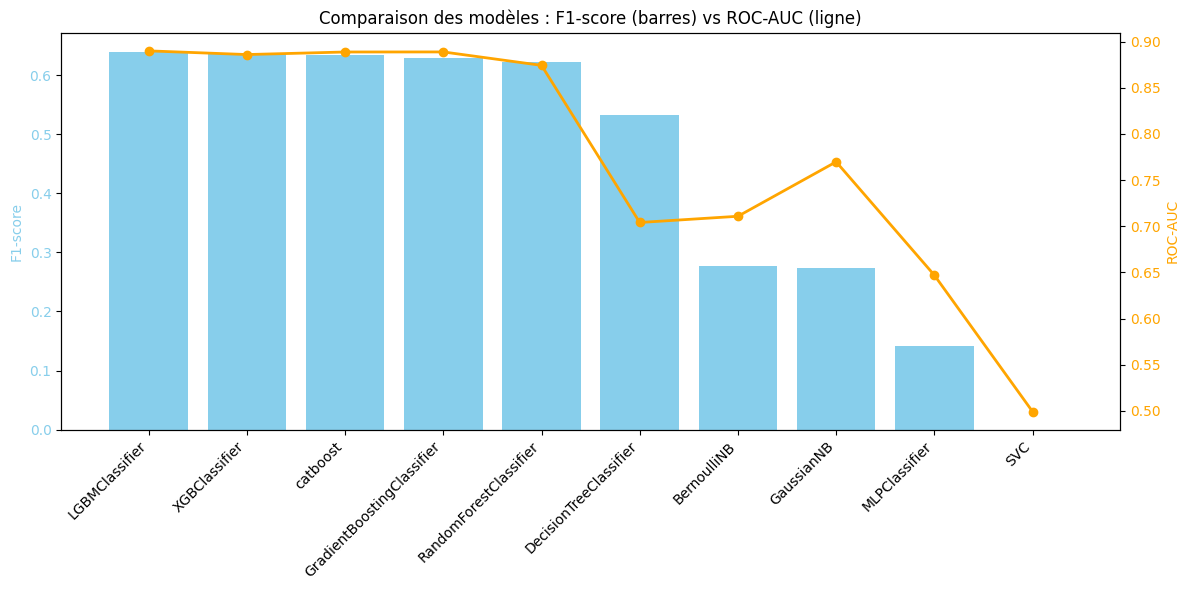


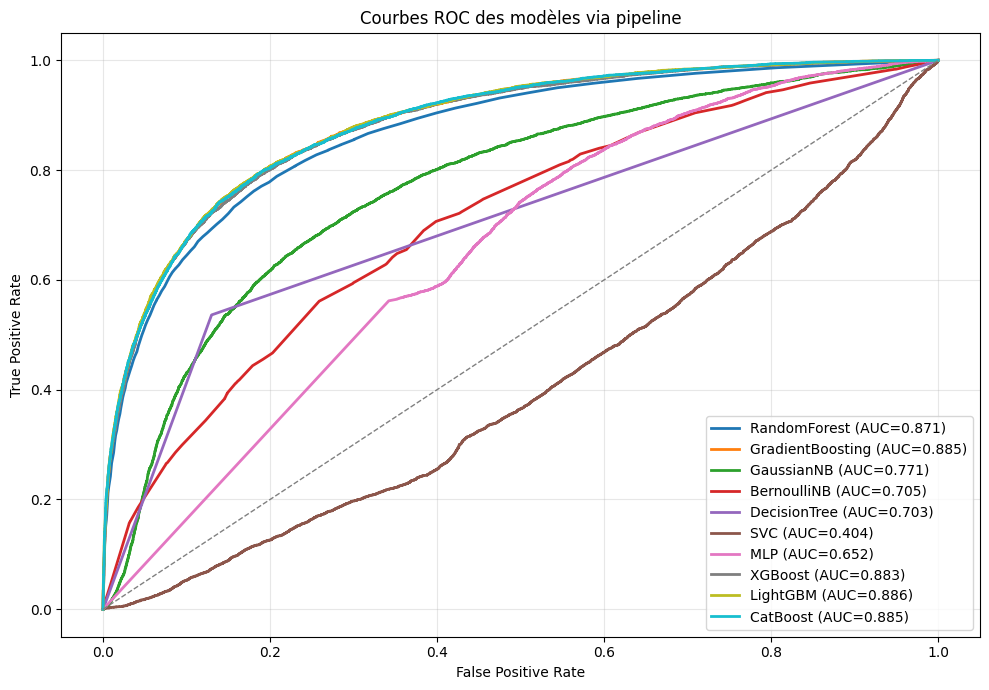


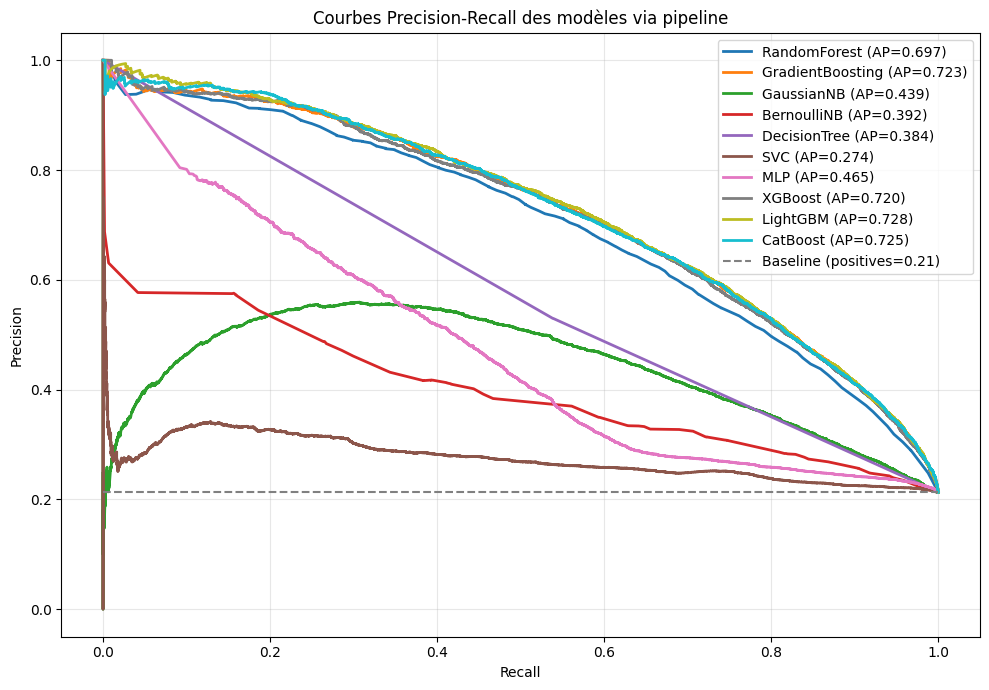

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


def afficher_performance(model: Pipeline):

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Plot confusion matrices
    # Plot confusion matrices
    sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Training Confusion Matrix (Accuracy: {f1_score(y_train, y_train_pred):.4f})')

    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title(f'Test Confusion Matrix (Accuracy: {f1_score(y_test, y_test_pred):.4f})')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()


    print("Classification Report (Training):")
    print(classification_report(y_train, y_train_pred))

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))


#### Observation:
On va utiliser LGBMClassifier / XGBClassifier

### Optimisation du preprocessing

In [19]:
estimator.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('encoder',
                                    OneHotEncoder(drop='first',
                                                  sparse_output=False),
                                    ['Geography', 'Gender'])],
                     verbose_feature_names_out=False)),
  ('oversampling', SMOTE(random_state=0)),
  ('classifier', LogisticRegression())],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('encoder',
                                  OneHotEncoder(drop='first',
                                                sparse_output=False),
                                  ['Geography', 'Gender'])],
                   verbose_feature_names_out=False),
 'oversampling': SMOTE(random_state=0),
 'classifier': LogisticRegression(),
 'preprocessing__force_int_remainder_cols': True

### Optimisation des modèles

In [23]:
from lightgbm import LGBMClassifier
from sklearn.preprocessing import OrdinalEncoder

param_grid = [
    {
        "preprocessing__encoder": [OrdinalEncoder()],  # Fixer lors d´une précédente GridSearch
        'classifier': [
            LGBMClassifier(
                random_state=RANDOM_STATE,
                n_jobs=0,
                learning_rate=0.05, 
                # num_leaves=225, 
                max_depth=7, 
                n_estimators=20
            )
            ], # Fixer lors d´une précédente GridSearch
        'classifier__boosting_type': ['gbdt', 'dart', 'rf'],
        # 'classifier__boosting_type': ['gbdt', 'dart', 'rf'],
        'classifier__num_leaves': [75, 175, 225],
        # 'classifier__num_leaves': [225, 500, -1],
        # 'classifier__max_depth': [-1, 6, 7, 8],  # 2^max_depth=num_leaves > 31 donc valide
        # 'classifier__n_estimators': [10, 20, 30, 50],
        # 'classifier__min_child_weight': [0.001, 0.01, 0.1],
        # 'classifier__max_bin': [32, 125, 255],
        'classifier__subsample': [0.8, 1],
        'classifier__colsample_bytree': [0.8, 1],
        'classifier__reg_lambda': [0, 0.2],
    },
]

# PARAMETRES DE PIPELINE DEJA ETUDIE

gs_result = run_gridsearch(estimator=estimator, params=param_grid, n_split=3)
best_model = gs_result.best_estimator_

Starting grid search...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 120712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, yo

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) 

[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 120712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356


...

[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356


[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) 

[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356
[LightGBM] [Info] Number of positive: 60356, number of negative: 60356


[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .



[LightGBM] [Info] Number of positive: 90534, number of negative: 90534
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 181068, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best parameters: {'classifier': LGBMClassifier(learning_rate=0.05, max_depth=7, n_estimators=20, n_jobs=0,
               random_state=0), 'classifier__boosting_type': 'gbdt', 'classifier__colsample_bytree': 1, 'classifier__num_leaves': 75, 'classifier__reg_lambda': 0, 'classifier__subsample': 0.8, 'preprocessing__encoder': OrdinalEncoder()}
Best F1-score: 0.6479642359495562


In [24]:
optimisation_scores = pd.DataFrame(gs_result.cv_results_)
optimisation_scores = optimisation_scores.sort_values(by=['mean_test_f1','mean_test_roc_auc'], ascending=False).head(10)

for col in optimisation_scores.columns:
    if 'param_' in col:
        print(f"{col :-<30} {optimisation_scores[col].unique()}")

param_classifier-------------- [LGBMClassifier(learning_rate=0.05, max_depth=7, n_estimators=20, n_jobs=0,
                random_state=0)                                            ]
param_classifier__boosting_type ['gbdt']
param_classifier__colsample_bytree [1.]
param_classifier__num_leaves-- [ 75 175 225]
param_classifier__reg_lambda-- [0.  0.2]
param_classifier__subsample--- [0.8 1. ]
param_preprocessing__encoder-- [OrdinalEncoder()]


("Meilleurs paramètres: {'classifier': LGBMClassifier(learning_rate=0.05, "
 'max_depth=7, n_estimators=20, n_jobs=0,\n'
 "               random_state=0), 'classifier__boosting_type': 'gbdt', "
 "'classifier__colsample_bytree': 1, 'classifier__num_leaves': 75, "
 "'classifier__reg_lambda': 0, 'classifier__subsample': 0.8, "
 "'preprocessing__encoder': OrdinalEncoder()}")


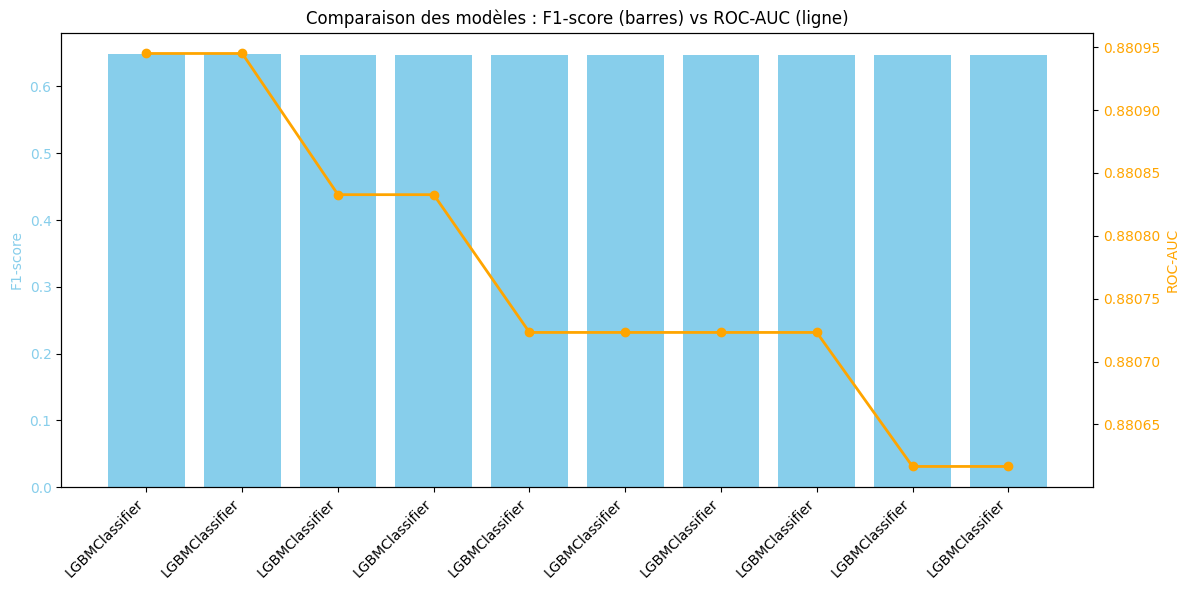

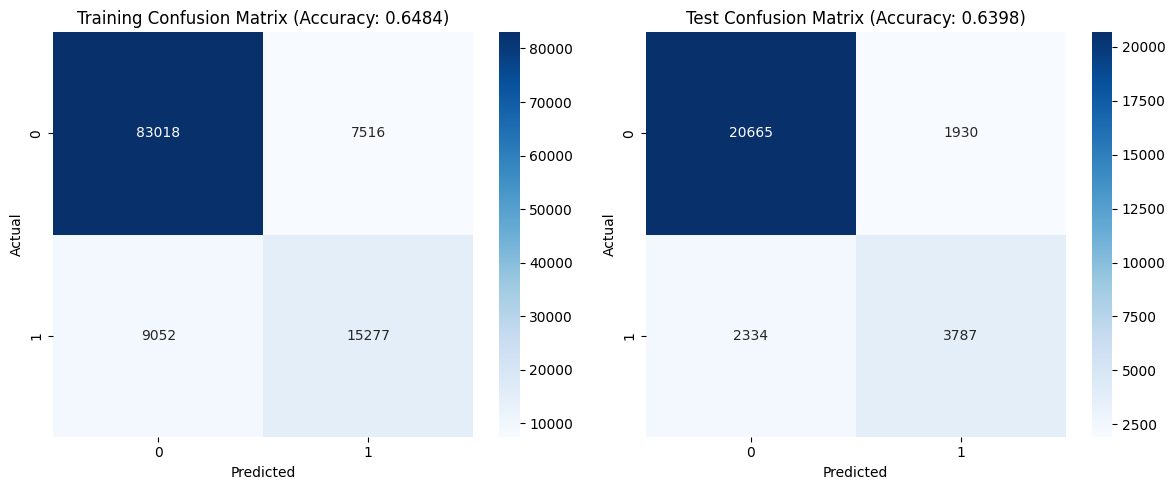

Classification Report (Training):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     90534
           1       0.67      0.63      0.65     24329

    accuracy                           0.86    114863
   macro avg       0.79      0.77      0.78    114863
weighted avg       0.85      0.86      0.85    114863


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     22595
           1       0.66      0.62      0.64      6121

    accuracy                           0.85     28716
   macro avg       0.78      0.77      0.77     28716
weighted avg       0.85      0.85      0.85     28716



In [25]:
from pprint import pprint


pprint(f"Meilleurs paramètres: {gs_result.best_params_}", indent=4, sort_dicts=True)
afficher_resultat(optimisation_scores)
afficher_performance(best_model)

In [16]:
gs_result.best_estimator_.named_steps

{'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('encoder', OrdinalEncoder(),
                                  ['Geography', 'Gender'])],
                   verbose_feature_names_out=False),
 'classifier': LGBMClassifier(colsample_bytree=1, is_unbalance=True, learning_rate=0.05,
                max_depth=7, n_estimators=20, n_jobs=0, num_leaves=75,
                random_state=0, reg_lambda=0, subsample=0.8)}

In [17]:
best_classifier = gs_result.best_estimator_.named_steps['classifier']

importances = best_classifier.booster_.feature_importance(importance_type='gain')
feature_names = best_classifier.booster_.feature_name()

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp

,Feature,Importance
3,Age,322378.988671
6,NumOfProducts,299146.506134
8,IsActiveMember,66324.218890
5,Balance,45718.071929
0,Geography,26138.711429
1,Gender,23145.430567
2,CreditScore,1630.436305
9,EstimatedSalary,1189.945693
7,HasCrCard,1165.461796
4,Tenure,780.518793


### Soumission

In [ ]:
# Entrainement sur l´ensemble du dataset
best_model.fit(X, y)

# Load the data
test_df = pd.read_csv("../data/test_data.csv", index_col='ID')

# Feature 'CustomerId' est une erreur est doit être éliminé
test_df.drop(columns='CustomerId', inplace=True)

# Feature 'Surname' n´a aucune signification pour notre projet
test_df.drop(columns='Surname', inplace=True)

result = best_model.predict(test_df)
submission_df = pd.DataFrame(result, columns=["Exited"], index=test_df.index)

submission_df.to_csv("../data/submission.csv")
check_df = pd.read_csv("../data/submission.csv")

check_df.head()

In [ ]:
import subprocess

competition = "mlpro-classification-bank-churn-2025"
file_path = "../data/submission.csv"
message = f"Utilisation des paramètres: {best_model.get_params()}"

result = subprocess.run(
    ["kaggle", "competitions", "submit", "-c", competition, "-f", file_path, "-m", message],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)
